# RadGenome-Brain MRI — EDA

Analyze GLI, MEN, ISLES22, and WMH. MET is excluded. One row represents one 3D MRI sequence.

Sources: [annotations](https://huggingface.co/datasets/JiayuLei/RadGenome-Brain_MRI), [author repository](https://github.com/ljy19970415/AutoRG-Brain), [paper](https://arxiv.org/html/2407.16684v3).


## 1. Environment
Keep `radgenome_utils.py` beside this notebook.


In [1]:
# %pip install -r radgenome_requirements.txt
from pathlib import Path
import sys, json, re, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

IN_COLAB = 'google.colab' in sys.modules
print('Environment:', 'Colab' if IN_COLAB else 'Local', '| Python:', sys.version.split()[0])
print({name: bool(importlib.util.find_spec(name)) for name in ['huggingface_hub', 'nibabel', 'scipy']})


Environment: Local | Python: 3.13.5
{'huggingface_hub': False, 'nibabel': False, 'scipy': True}


## 2. Paths
Read source data in place. Save tables and figures to `processed/` and `eda/`.


In [2]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT = Path('/content/drive/MyDrive/self_research/brain_vlm_xai')
else:
    candidates = [Path.cwd(), *Path.cwd().parents]
    PROJECT_ROOT = next((p for p in candidates if (p / 'notebooks' / 'radgenome_utils.py').exists()), None)
    if PROJECT_ROOT is None:
        raise FileNotFoundError('Set PROJECT_ROOT to the brain_vlm_xai project.')

sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))
import radgenome_utils as rg

DATA_ROOT = PROJECT_ROOT / 'datasets' / 'RadGenome-Brain_MRI'
qa_deps = DATA_ROOT / '.qa_dependencies'
if importlib.util.find_spec('nibabel') is None and qa_deps.exists():
    sys.path.insert(0, str(qa_deps))
ANNOTATION_DIR = DATA_ROOT / 'raw' / 'annotations'
SOURCE_DIR = DATA_ROOT / 'raw' / 'sources'
REFERENCE_DIR = DATA_ROOT / 'reference' / 'AutoRG-Brain'
PROCESSED_DIR = DATA_ROOT / 'processed'
EDA_DIR = DATA_ROOT / 'eda'
OVERRIDE_FILE = PROCESSED_DIR / 'path_overrides.csv'
DEFERRED_SOURCES = {'BraTS_MET': 'Excluded by user request'}
ACTIVE_SOURCES = tuple(s for s in rg.SOURCES if s not in DEFERRED_SOURCES)
EXCLUDED_ARCHIVES = {'BraTS-MEN-TRAIN-FIX-V4.zip'}
for p in [ANNOTATION_DIR, PROCESSED_DIR, EDA_DIR, EDA_DIR / 'figures', *[SOURCE_DIR / s for s in rg.SOURCES]]:
    p.mkdir(parents=True, exist_ok=True)
print('Data root:', DATA_ROOT)


Data root: D:\Research\brain_vlm_xai\datasets\RadGenome-Brain_MRI


### Storage
ZIP volumes are read in memory. No extraction or volume cache.


In [3]:
import shutil, datetime, zipfile
disk_start = shutil.disk_usage(DATA_ROOT)
eda_bytes_before = sum(p.stat().st_size for p in DATA_ROOT.rglob('*') if p.is_file()
                       and ('eda' in p.parts or 'processed' in p.parts))
print('Free on data disk (GiB):', round(disk_start.free / 1024**3, 2))
if disk_start.free < 1024**3:
    raise OSError('Less than 1 GiB free on the data disk.')
archive_rows = []
for archive in sorted(SOURCE_DIR.rglob('*.zip')):
    if archive.parent.name not in ACTIVE_SOURCES:
        continue
    try:
        with zipfile.ZipFile(archive) as z:
            members = [i for i in z.infolist() if not i.is_dir()]
    except (OSError, zipfile.BadZipFile) as exc:
        archive_rows.append({'source': archive.parent.name, 'archive': archive.name,
                             'archive_gib': archive.stat().st_size / 1024**3,
                             'archive_status': type(exc).__name__, 'selected_for_linking': False})
        continue
    archive_rows.append({'source':archive.parent.name, 'archive':archive.name,
                             'archive_gib': archive.stat().st_size / 1024**3,
                             'member_gib':sum(i.file_size for i in members) / 1024**3,
                             'member_count':len(members), 'archive_status':'readable',
                             'selected_for_linking': archive.name not in EXCLUDED_ARCHIVES})
archive_inventory = pd.DataFrame(archive_rows)
display(archive_inventory)
archive_inventory.to_csv(EDA_DIR / 'archive_inventory.csv',index=False)


Free on data disk (GiB): 9.42


,source,archive,archive_gib,member_gib,member_count,archive_status,selected_for_linking
0,BraTS_GLI,ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingDa...,12.267955,12.469979,6255,readable,True
1,BraTS_GLI,ASNR-MICCAI-BraTS2023-GLI-Challenge-Validation...,2.200889,2.228601,876,readable,True
2,BraTS_MEN,ASNR-MICCAI-BraTS2023-MEN-Challenge-TrainingDa...,18.792384,19.274224,5000,readable,True
3,BraTS_MEN,ASNR-MICCAI-BraTS2023-MEN-Challenge-Validation...,2.635228,2.694557,564,readable,True
4,BraTS_MEN,BraTS-MEN-TRAIN-FIX-V4.zip,0.867717,0.890249,236,readable,False
5,ISLES22,ISLES-2022.zip,1.576466,1.637807,1688,readable,True


## 3. Annotation provenance
Use the pinned Hugging Face release. Download is disabled by default.


In [4]:
DOWNLOAD_ANNOTATIONS = False
HF_REPO = 'JiayuLei/RadGenome-Brain_MRI'
HF_REVISION = '0348ba42fad134da57b50e736ba858a8e73eb086'

if DOWNLOAD_ANNOTATIONS:
    from huggingface_hub import snapshot_download
    import hashlib, datetime
    snapshot_download(repo_id=HF_REPO, repo_type='dataset', revision=HF_REVISION,
                      local_dir=str(ANNOTATION_DIR), allow_patterns=['*.json', '*.md', '.gitattributes'])
    files = []
    for p in sorted(ANNOTATION_DIR.rglob('*')):
        if p.is_file() and '.cache' not in p.parts and p.name != 'download_manifest.json':
            name = p.relative_to(ANNOTATION_DIR).as_posix()
            files.append({'file': name, 'sha256': rg.file_sha256(p), 'bytes': p.stat().st_size,
                          'url': f'https://huggingface.co/datasets/{HF_REPO}/resolve/{HF_REVISION}/{name}'})
    (ANNOTATION_DIR / 'download_manifest.json').write_text(json.dumps({
        'hf_revision': HF_REVISION, 'downloaded_at_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(),
        'files': files}, indent=2), encoding='utf-8')
else:
    print('Using local annotations.')

expected = [ANNOTATION_DIR / 'train_val_test_split.json'] + [
    ANNOTATION_DIR / s / f for s in rg.SOURCES
    for f in ['global_finding.json', 'impression.json', 'modal_wise_finding.json']]
missing = [str(p) for p in expected if not p.is_file()]
if missing:
    raise FileNotFoundError('Missing annotation files: ' + str(missing))
print('Annotation files OK:', len(expected))
provenance_path = ANNOTATION_DIR / 'download_manifest.json'
if provenance_path.exists():
    provenance = rg.read_json(provenance_path)
    print('Revision:', provenance.get('hf_revision'), '| GitHub:', provenance.get('github_commit'))
    bad_hashes = [x['file'] for x in provenance['files'] if x.get('provider', 'huggingface') == 'huggingface'
                  and rg.file_sha256(ANNOTATION_DIR / x['file']) != x['sha256']]
    if bad_hashes:
        raise ValueError('Checksum mismatch: ' + str(bad_hashes))


Using local annotations.
Annotation files OK: 16
Revision: 0348ba42fad134da57b50e736ba858a8e73eb086 | GitHub: 9670703c88e8f599c0c7edc472a5ffce4dd72b0e


## 4. Dataset overview
The original release contains 1,007 cases and 3,408 sequence IDs. Global findings are case-level; modality findings are GPT-4 decompositions. Lesion masks come from the source datasets.

The author repository separates segmentation and report tasks. This notebook uses explicit image, lesion-mask, and report fields.


In [5]:
card = {'dataset': 'RadGenome-Brain MRI', 'unit': '3D MRI sequence',
        'published_cases': 1007, 'published_image_ids': 3408,
        'tasks': 'regional report generation; lesion grounding',
        'sources': list(rg.SOURCES), 'modalities': ['T1WI', 'T1CE', 'T2WI', 'T2FLAIR', 'ADC', 'DWI'],
        'anatomy_masks': 'not in HF annotation release; pseudo-labels if generated',
        'MRI_volumes_in_original_HF_release': False}
display(pd.Series(card))


dataset                                                             RadGenome-Brain MRI
unit                                                                    3D MRI sequence
published_cases                                                                    1007
published_image_ids                                                                3408
tasks                                      regional report generation; lesion grounding
sources                                 [BraTS_GLI, BraTS_MEN, BraTS_MET, ISLES22, WMH]
modalities                                        [T1WI, T1CE, T2WI, T2FLAIR, ADC, DWI]
anatomy_masks                         not in HF annotation release; pseudo-labels if...
MRI_volumes_in_original_HF_release                                                False
dtype: object

## 5. Annotation schema
Load the original JSON files and retain missing reports.


In [6]:
all_annotations, schema, official_splits = rg.load_annotations(ANNOTATION_DIR)
annotations = all_annotations.loc[all_annotations.source.isin(ACTIVE_SOURCES)].copy()
all_annotations.to_csv(PROCESSED_DIR / 'original_annotation_catalog.csv', index=False)
pd.DataFrame([{'source': s, 'reason': reason,
               'deferred_image_ids': int(all_annotations.source.eq(s).sum())}
              for s,reason in DEFERRED_SOURCES.items()]).to_csv(EDA_DIR / 'deferred_sources.csv',index=False)
print('Original release IDs:', len(all_annotations), '| active scope IDs:', len(annotations))
display(schema)
display(annotations[['source','image_id','case_id','modality','split']].head())
display(pd.DataFrame({'rows': {k: len(v) for k,v in official_splits.items()},
                      'unique_ids': {k: len(set(v)) for k,v in official_splits.items()}}))
print('IDs:', len(annotations), '| Cases:', annotations[['source','case_id']].drop_duplicates().shape[0])
print('Modal reports:', annotations.modal_finding.notna().sum(), '| Missing:', annotations.modal_finding.isna().sum())


Original release IDs: 3408 | active scope IDs: 2460


,source,file,records,value_types
0,BraTS_GLI,modal_wise_finding.json,920,str
1,BraTS_GLI,global_finding.json,230,str
2,BraTS_GLI,impression.json,230,dict
3,BraTS_MEN,modal_wise_finding.json,920,str
4,BraTS_MEN,global_finding.json,230,str
5,BraTS_MEN,impression.json,230,dict
6,BraTS_MET,modal_wise_finding.json,948,str
7,BraTS_MET,global_finding.json,237,str
8,BraTS_MET,impression.json,237,dict
9,ISLES22,modal_wise_finding.json,250,str


,source,image_id,case_id,modality,split
0,BraTS_GLI,BraTS-GLI-00006-000-t1c,BraTS-GLI-00006-000,T1CE,test
1,BraTS_GLI,BraTS-GLI-00006-000-t1n,BraTS-GLI-00006-000,T1WI,test
2,BraTS_GLI,BraTS-GLI-00006-000-t2f,BraTS-GLI-00006-000,T2FLAIR,test
3,BraTS_GLI,BraTS-GLI-00006-000-t2w,BraTS-GLI-00006-000,T2WI,test
4,BraTS_GLI,BraTS-GLI-00012-000-t1c,BraTS-GLI-00012-000,T1CE,val


,rows,unique_ids
test,688,688
train,2382,2382
val,338,338


IDs: 2460 | Cases: 770
Modal reports: 2150 | Missing: 310


## 6. Coverage and split audit
2,150 of 2,460 sequences have modality reports (87.4%). Missing reports: 250 ISLES DWI and 60 WMH T1. Three MEN patient-ID proxies cross splits.


image_ids  modal_reports  cases  missing_reports
source    modality                                                  
BraTS_GLI T1CE            230            230    230                0
          T1WI            230            230    230                0
          T2FLAIR         230            230    230                0
          T2WI            230            230    230                0
BraTS_MEN T1CE            230            230    230                0
          T1WI            230            230    230                0
          T2FLAIR         230            230    230                0
          T2WI            230            230    230                0
ISLES22   ADC             250            250    250                0
          DWI             250              0    250              250
WMH       T1WI             60              0     60               60
          T2FLAIR          60             60     60                0

,modal_finding,global_finding,impression
source,,,
BraTS_GLI,0,0,0
BraTS_MEN,0,0,0
ISLES22,250,0,0
WMH,60,0,0


split,test,train,val
source,,,
BraTS_GLI,184,644,92
BraTS_MEN,184,644,92
ISLES22,100,350,50
WMH,24,84,12


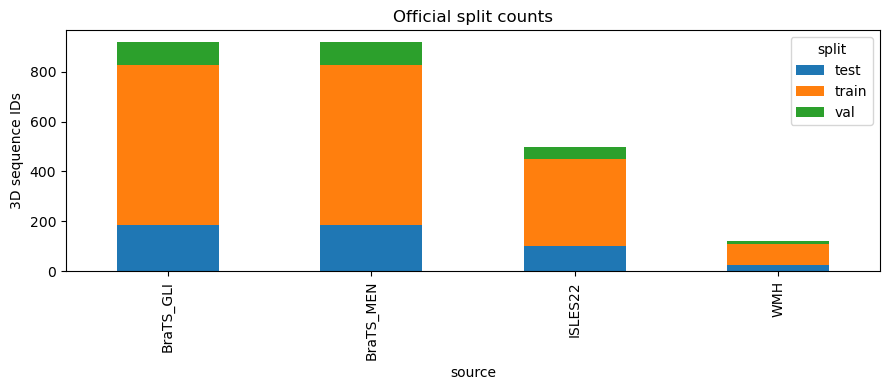

,level,source,id,splits
0,patient_id_proxy,BraTS_MEN,BraTS-MEN-00074,test|train
1,patient_id_proxy,BraTS_MEN,BraTS-MEN-00932,train|val
2,patient_id_proxy,BraTS_MEN,BraTS-MEN-01246,train|val


Repeated IDs inside split: 0
Zero overlap at case level does not establish patient independence.


In [7]:
coverage = annotations.groupby(['source','modality']).agg(
    image_ids=('image_id','size'), modal_reports=('modal_finding','count'), cases=('case_id','nunique'))
coverage['missing_reports'] = coverage.image_ids - coverage.modal_reports
display(coverage)
display(annotations.groupby('source')[['modal_finding','global_finding','impression']].apply(lambda x: x.isna().sum()))
split_counts = pd.crosstab(annotations.source, annotations.split)
display(split_counts)
split_counts.plot.bar(stacked=True, figsize=(9,4), ylabel='3D sequence IDs', title='Official split counts')
plt.tight_layout(); plt.savefig(EDA_DIR / 'figures' / 'split_counts.png', dpi=150); plt.show()

leakage = rg.leakage_audit(annotations)
display(leakage)
print('Repeated IDs inside split:', int((annotations.split_occurrences > 1).sum()))
leakage.to_csv(EDA_DIR / 'split_overlap_audit.csv', index=False)
print('Zero overlap at case level does not establish patient independence.')


## 7. Modality completeness
Count cases separately from MRI sequences.


modality                       ADC  DWI  T1CE  T1WI  T2FLAIR  T2WI
source    case_id                                                 
BraTS_GLI BraTS-GLI-00006-000    0    0     1     1        1     1
          BraTS-GLI-00012-000    0    0     1     1        1     1
          BraTS-GLI-00014-001    0    0     1     1        1     1
          BraTS-GLI-00017-000    0    0     1     1        1     1
          BraTS-GLI-00021-000    0    0     1     1        1     1

,sequence_ids,cases,patient_proxies
source,,,
BraTS_GLI,920,230,228
BraTS_MEN,920,230,226
ISLES22,500,250,250
WMH,120,60,60


modality,ADC,DWI,T1CE,T1WI,T2FLAIR,T2WI
source,,,,,,
BraTS_GLI,0,0,230,230,230,230
BraTS_MEN,0,0,230,230,230,230
ISLES22,250,250,0,0,0,0
WMH,0,0,0,60,60,0


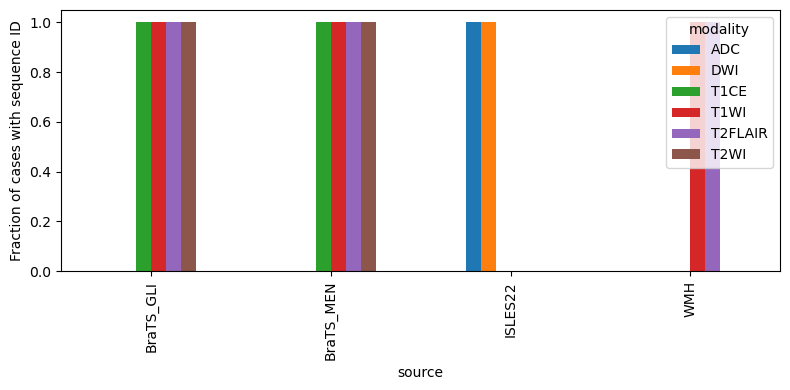

In [8]:
case_modality = pd.crosstab([annotations.source, annotations.case_id], annotations.modality).clip(upper=1)
display(case_modality.head())
display(annotations.groupby('source').agg(sequence_ids=('image_id','size'), cases=('case_id','nunique'),
                                         patient_proxies=('patient_id_proxy','nunique')))
display(case_modality.groupby(level='source').sum())
fig, ax = plt.subplots(figsize=(8,4))
case_modality.groupby(level='source').mean().plot(kind='bar', ax=ax, ylabel='Fraction of cases with sequence ID')
plt.tight_layout(); plt.show()


## 8. Report length and duplicates
Median words: GLI 36, MEN 33, ISLES 28, WMH 21.5. Ten modality reports form five exact normalized-text duplicate groups.


count       mean        std   min    25%   50%    75%  \
source    modality                                                          
BraTS_GLI T1CE      230.0  35.652174  11.922269  12.0  26.00  36.0  45.00   
          T1WI      230.0  42.808696  10.208221  15.0  36.00  42.0  49.00   
          T2FLAIR   230.0  32.986957  10.342806  10.0  25.00  32.0  40.75   
          T2WI      230.0  33.943478   9.898671   9.0  27.00  34.0  41.00   
BraTS_MEN T1CE      230.0  34.639130  10.653955   8.0  29.25  35.0  41.00   
          T1WI      230.0  36.578261   9.496056  15.0  30.00  36.0  43.00   
          T2FLAIR   230.0  29.639130   9.165877  10.0  22.25  30.0  35.75   
          T2WI      230.0  31.234783   8.592503  13.0  25.00  31.0  37.00   
ISLES22   ADC       250.0  28.060000   6.390285  13.0  24.00  28.0  32.00   
          DWI         0.0        NaN        NaN   NaN    NaN   NaN    NaN   
WMH       T1WI        0.0        NaN        NaN   NaN    NaN   NaN    NaN   
          T2FLAIR    60.0  25.100000   9.000377   8.0  19.00  21.5  31.00   

                     max  
source    modality        
BraTS_GLI T1CE      65.0  
          T1WI      73.0  
          T2FLAIR   60.0  
          T2WI      62.0  
BraTS_MEN T1CE      68.0  
          T1WI      67.0  
          T2FLAIR   54.0  
          T2WI      56.0  
ISLES22   ADC       47.0  
          DWI        NaN  
WMH       T1WI       NaN  
          T2FLAIR   48.0

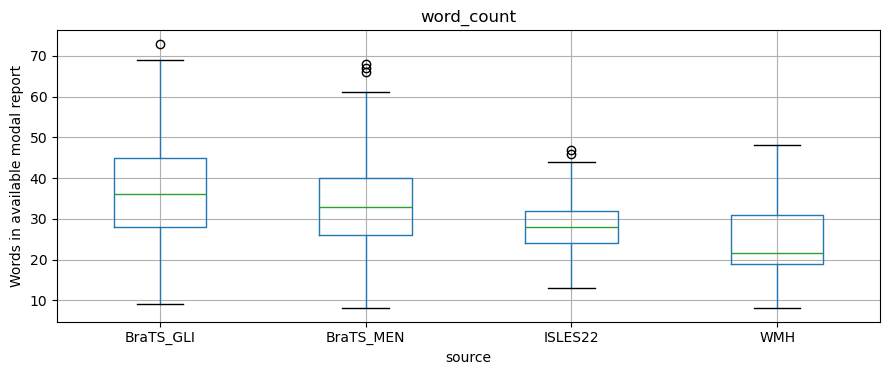

modal_finding | non-empty: 2150 | rows participating in exact normalized duplicates: 10
global_finding | non-empty: 770 | rows participating in exact normalized duplicates: 0
impression | non-empty: 770 | rows participating in exact normalized duplicates: 57


In [9]:
text_df = annotations.copy()
text_df['word_count'] = text_df.modal_finding.map(lambda x: len(x.split()) if isinstance(x,str) else np.nan)
text_df['char_count'] = text_df.modal_finding.map(lambda x: len(x) if isinstance(x,str) else np.nan)
display(text_df.groupby(['source','modality']).word_count.describe())
text_df.boxplot(column='word_count', by='source', figsize=(9,4))
plt.suptitle(''); plt.ylabel('Words in available modal report'); plt.tight_layout(); plt.show()
case_text = annotations.drop_duplicates(['source','case_id'])
for col, frame in [('modal_finding', annotations), ('global_finding', case_text), ('impression', case_text)]:
    available = frame.loc[frame[col].map(lambda x: isinstance(x, str) and bool(x.strip()))].copy()
    available['normalized'] = available[col].map(lambda x: ' '.join(x.lower().split()))
    print(col, '| non-empty:', len(available), '| rows participating in exact normalized duplicates:',
          int(available.normalized.duplicated(keep=False).sum()))


## 9. Report terminology
Term frequencies count mentions, including negated statements; they are not diagnostic labels.


In [10]:
patterns = {'left': r'\bleft\b', 'right': r'\bright\b', 'bilateral': r'\bbilateral\b',
            'edema': r'\b(?:edema|oedema)\b', 'enhancement': r'\benhanc\w*',
            'midline': r'\bmidline\b', 'negation_mention': r'\b(?:no|without|not)\b'}
mentions = pd.DataFrame({k: annotations.modal_finding.fillna('').str.contains(v,case=False,regex=True)
                         for k,v in patterns.items()})
mentions['source'] = annotations.source
mention_counts = mentions.groupby('source').sum()
denominator = annotations.groupby('source').modal_finding.count()
display(mention_counts.div(denominator,axis=0).round(3))
disease_rows = []
for r in case_text.itertuples(index=False):
    for term in json.loads(r.disease_terms):
        disease_rows.append({'source': r.source, 'case_id': r.case_id, 'term': term})
disease_terms = pd.DataFrame(disease_rows)
display(disease_terms.groupby(['source','term']).case_id.nunique().sort_values(ascending=False).head(25))
print('Disease terms are report-derived; do not interpret as confirmed histology.')


,left,right,bilateral,edema,enhancement,midline,negation_mention
source,,,,,,,
BraTS_GLI,0.570,0.459,0.050,0.628,0.251,0.655,0.335
BraTS_MEN,0.395,0.434,0.032,0.428,0.253,0.722,0.615
ISLES22,0.400,0.456,0.160,0.004,0.000,0.980,0.972
WMH,0.083,0.150,0.033,0.017,0.000,0.983,0.967


source     term                                            
BraTS_GLI  Malignant tumor                                     126
BraTS_MEN  Meningioma                                          125
           meningioma                                           78
BraTS_GLI  malignant tumor                                      67
           Glioblastoma                                         61
WMH        Periventricular white matter degeneration            58
BraTS_GLI  glioblastoma                                         34
           Glioblastoma multiforme                              26
           Glioblastoma with possible hemorrhage                19
           glioblastoma multiforme                              18
           Hemorrhage                                           17
           Malignancy                                           14
ISLES22    Small patchy infarcts in the subacute phase          12
           Small patchy infarcts (subacute phase)               11
  

Disease terms are report-derived; do not interpret as confirmed histology.


## 10. Image–mask linking
Match exact IDs. Use MEN train v3; keep FIX-V4 out of linking. For WMH, link training images and primary masks only.


In [11]:
if not OVERRIDE_FILE.exists():
    pd.DataFrame(columns=['source','image_id','image_path','lesion_mask_path','source_version','mapping_evidence']).to_csv(OVERRIDE_FILE,index=False)
manifest, inventory = rg.link_files(annotations, SOURCE_DIR, OVERRIDE_FILE,
                                    excluded_archives=EXCLUDED_ARCHIVES, active_sources=ACTIVE_SOURCES)
men_v3 = manifest.source.eq('BraTS_MEN') & manifest.image_status.eq('matched')
manifest.loc[men_v3, 'source_version'] = 'BraTS2023-MEN syn51514055 version 3'
manifest.loc[men_v3, 'mapping_evidence'] = 'Exact filename ID; successful Synapse v3 download log; FIX-V4 excluded'
wmh_rows = manifest.source.eq('WMH') & manifest.image_status.eq('matched')
manifest.loc[wmh_rows, 'source_version'] = 'WMH DOI 10.34894/AECRSD v1.0'
manifest.loc[wmh_rows, 'mapping_evidence'] = 'Training path and exact ID; Dataverse file checksums verified during download'
manifest.to_csv(PROCESSED_DIR / 'image_report_manifest.csv',index=False)
inventory.to_csv(EDA_DIR / 'nifti_inventory.csv',index=False)
display(manifest.groupby(['source','image_status','lesion_mask_status']).size().rename('sequence_ids').to_frame())

print('NIfTI files discovered:', len(inventory))


,,,sequence_ids
source,image_status,lesion_mask_status,
BraTS_GLI,matched,matched,920
BraTS_MEN,matched,matched,920
ISLES22,matched,matched,500
WMH,matched,matched,120


NIfTI files discovered: 15550


### Local coverage
All 770 cases and 2,460 sequences have linked images and masks. No active image IDs are missing.


In [12]:
local_coverage = manifest.assign(
    image_available=manifest.image_status.isin(['matched','manual_override']),
    mask_available=manifest.lesion_mask_status.isin(['matched','manual_override']),
    report_available=manifest.modal_finding.notna())
local_coverage['image_mask_report_available'] = local_coverage[['image_available','mask_available','report_available']].all(axis=1)
local_summary = local_coverage.groupby('source').agg(required_cases=('case_id','nunique'),
    required_images=('image_id','size'), local_images=('image_available','sum'),
    local_masks_sequence_rows=('mask_available','sum'), image_mask_report_rows=('image_mask_report_available','sum'))
local_cases = local_coverage.loc[local_coverage.image_available].groupby('source').case_id.nunique()
local_summary['local_cases'] = local_cases.reindex(local_summary.index,fill_value=0)
display(local_summary)
local_summary.to_csv(EDA_DIR / 'local_source_coverage.csv')
display(inventory.groupby(['source','archive','kind']).size().rename('files'))


,required_cases,required_images,local_images,local_masks_sequence_rows,image_mask_report_rows,local_cases
source,,,,,,
BraTS_GLI,230,920,920,920,920,230
BraTS_MEN,230,920,920,920,920,230
ISLES22,250,500,500,500,250,250
WMH,60,120,120,120,60,60


source     archive                                                 kind        
BraTS_GLI  ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData.zip    image           5004
                                                                   lesion_mask     1251
           ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData.zip  image            876
BraTS_MEN  ASNR-MICCAI-BraTS2023-MEN-Challenge-TrainingData.zip    image           4000
                                                                   lesion_mask     1000
           ASNR-MICCAI-BraTS2023-MEN-Challenge-ValidationData.zip  image            564
           BraTS-MEN-TRAIN-FIX-V4.zip                              image            188
                                                                   lesion_mask       47
ISLES22    ISLES-2022.zip                                          image            750
                                                                   lesion_mask      250
WMH                                     

## 11. Missing images
Export required-case lists and unresolved image IDs. MET remains excluded.


In [13]:
for source, group in manifest.groupby('source'):
    needed = group.groupby('case_id').agg(modalities=('modality', lambda x: '|'.join(sorted(set(x)))),
        image_ids=('image_id',lambda x:'|'.join(sorted(x))), splits=('split',lambda x:'|'.join(sorted(set(x)))))
    needed.to_csv(PROCESSED_DIR / f'required_cases_{source}.csv')
manifest.loc[~manifest.image_status.isin(['matched','manual_override']),
             ['source','case_id','image_id','modality','split','image_status']].to_csv(PROCESSED_DIR/'missing_images.csv',index=False)
display(manifest.groupby('source').agg(required_cases=('case_id','nunique'), required_images=('image_id','size')))
print('Download guide:', PROJECT_ROOT / 'RADGENOME_DOWNLOAD_GUIDE.md')


,required_cases,required_images
source,,
BraTS_GLI,230,920
BraTS_MEN,230,920
ISLES22,250,500
WMH,60,120


Download guide: D:\Research\brain_vlm_xai\RADGENOME_DOWNLOAD_GUIDE.md


## 12. Header QC
2,446 sequences pass geometry QC. Fourteen have qform/sform conflicts across six ISLES cases and WMH Singapore_63. MEN spatial units remain unspecified.


In [14]:
HAS_NIBABEL = importlib.util.find_spec('nibabel') is not None
headers = pd.DataFrame()
if HAS_NIBABEL:
    headers = rg.header_audit(manifest)
    headers.to_csv(EDA_DIR / 'image_mask_header_qc.csv',index=False)
    display(headers.groupby(['source','qc_status']).size().rename('sequence_ids').to_frame())
    if all(c in headers.columns for c in ['sx','sy','sz']):
        display(headers.groupby('source')[['sx','sy','sz']].agg(['min','median','max']))
        display(headers.groupby(['source','orientation']).size().rename('sequence_ids'))
else:
    print('Install nibabel to run image QC.')


sequence_ids
source    qc_status                         
BraTS_GLI aligned                        920
BraTS_MEN aligned                        920
ISLES22   aligned                        488
          qform_sform_conflict            12
WMH       aligned                        118
          qform_sform_conflict             2

sx                    sy                     sz         \
                min median  max       min  median  max       min median   
source                                                                    
BraTS_GLI  1.000000    1.0  1.0  1.000000  1.0000  1.0  1.000000    1.0   
BraTS_MEN  1.000000    1.0  1.0  1.000000  1.0000  1.0  1.000000    1.0   
ISLES22    0.875000    2.0  2.0  0.875000  2.0000  2.0  2.000000    2.0   
WMH        0.958333    1.0  1.2  0.958333  0.9766  1.0  2.999997    3.0   

                     
                max  
source               
BraTS_GLI  1.000000  
BraTS_MEN  1.000000  
ISLES22    5.000000  
WMH        3.000005

source     orientation
BraTS_GLI  LPS            920
BraTS_MEN  LPS            920
ISLES22    LAS            500
WMH        LPS            120
Name: sequence_ids, dtype: int64

### Full-cohort mask QC
All 770 masks have valid labels. Three ISLES masks are empty. Physical volumes are withheld when units or geometry are unresolved.


In [15]:
cohort_masks = rg.cohort_mask_audit(headers) if HAS_NIBABEL and not headers.empty else pd.DataFrame()
if not cohort_masks.empty:
    cohort_masks.to_csv(EDA_DIR / 'cohort_mask_qc.csv',index=False)
    display(cohort_masks.groupby(['source','qc_status']).size().rename('cases'))
    display(cohort_masks.groupby('source')[['lesion_voxels','lesion_ml']].describe())
    display(cohort_masks.groupby('source').empty_mask.sum().rename('empty_masks'))
    cohort_masks.groupby('source')[['lesion_voxels','lesion_ml']].describe().to_csv(EDA_DIR / 'cohort_lesion_statistics.csv')


source     qc_status
BraTS_GLI  read_ok      230
BraTS_MEN  read_ok      230
ISLES22    read_ok      250
WMH        read_ok       60
Name: cases, dtype: int64

lesion_voxels                                                \
                  count          mean           std     min       25%   
source                                                                  
BraTS_GLI         230.0  96373.665217  56707.148687  2808.0  50515.25   
BraTS_MEN         230.0  45392.443478  66319.834163   135.0   1417.75   
ISLES22           250.0   2900.556000   5985.166309     0.0    197.25   
WMH                60.0   5921.333333   6125.886528   262.0    939.50   

                                        lesion_ml                        \
               50%        75%       max     count       mean        std   
source                                                                    
BraTS_GLI  91720.0  134998.00  284681.0     230.0  96.373665  56.707149   
BraTS_MEN  13141.5   64716.25  321447.0       0.0        NaN        NaN   
ISLES22      773.5    2696.75   60269.0     244.0  23.408631  47.295514   
WMH         4761.5    8800.00   27218.0      59.0  17.300606  17.356129   

                                                                
             min        25%        50%         75%         max  
source                                                          
BraTS_GLI  2.808  50.515250  91.720000  134.998000  284.681000  
BraTS_MEN    NaN        NaN        NaN         NaN         NaN  
ISLES22    0.000   1.554001   6.604579   21.135620  482.151993  
WMH        0.786   3.069259  14.550003   25.268889   74.991385

source
BraTS_GLI    0
BraTS_MEN    0
ISLES22      3
WMH          0
Name: empty_masks, dtype: int64

## 13. Case-level voxel QC
All 763 geometry-eligible cases were audited. Median connected components: GLI 2, MEN 1, ISLES 5, WMH 57. Components describe fragmentation, not clinical lesion counts.


,source,case_id,image_id,modality,image_path,lesion_mask_path,image_nonfinite,zero_fraction,mask_labels,mask_valid,unexpected_labels,p01,p50,p99,lesion_voxels,empty_mask,components_26,lesion_ml,volume_unit_status,qc_status
0,BraTS_GLI,BraTS-GLI-00006-000,BraTS-GLI-00006-000-t1c,T1CE,zip://D:\Research\brain_vlm_xai\datasets\RadGe...,zip://D:\Research\brain_vlm_xai\datasets\RadGe...,0,0.829794,"[0.0, 1.0, 2.0, 3.0]",True,[],0.0,0.0,3097.000000,137911,False,1,137.911,known,read_ok
1,BraTS_GLI,BraTS-GLI-00012-000,BraTS-GLI-00012-000-t1n,T1WI,zip://D:\Research\brain_vlm_xai\datasets\RadGe...,zip://D:\Research\brain_vlm_xai\datasets\RadGe...,0,0.817278,"[0.0, 1.0, 2.0, 3.0]",True,[],0.0,0.0,1000.000000,263809,False,1,263.809,known,read_ok
2,BraTS_GLI,BraTS-GLI-00014-001,BraTS-GLI-00014-001-t2f,T2FLAIR,zip://D:\Research\brain_vlm_xai\datasets\RadGe...,zip://D:\Research\brain_vlm_xai\datasets\RadGe...,0,0.844699,"[0.0, 1.0, 2.0, 3.0]",True,[],0.0,0.0,447.802863,38600,False,1,38.600,known,read_ok
3,BraTS_GLI,BraTS-GLI-00017-000,BraTS-GLI-00017-000-t2w,T2WI,zip://D:\Research\brain_vlm_xai\datasets\RadGe...,zip://D:\Research\brain_vlm_xai\datasets\RadGe...,0,0.823333,"[0.0, 1.0, 2.0, 3.0]",True,[],0.0,0.0,1735.000000,99385,False,1,99.385,known,read_ok
4,BraTS_GLI,BraTS-GLI-00021-000,BraTS-GLI-00021-000-t1c,T1CE,zip://D:\Research\brain_vlm_xai\datasets\RadGe...,zip://D:\Research\brain_vlm_xai\datasets\RadGe...,0,0.837633,"[0.0, 1.0, 2.0, 3.0]",True,[],0.0,0.0,2985.000000,89260,False,2,89.260,known,read_ok


source     qc_status
BraTS_GLI  read_ok      230
BraTS_MEN  read_ok      230
ISLES22    read_ok      244
WMH        read_ok       59
Name: audited_cases, dtype: int64

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
BraTS_GLI,230.0,96.373665,56.707149,2.808,50.515250,91.720000,134.998000,284.681000
BraTS_MEN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ISLES22,244.0,23.408631,47.295514,0.000,1.554001,6.604579,21.135620,482.151993
WMH,59.0,17.300606,17.356129,0.786,3.069258,14.550002,25.268891,74.991389


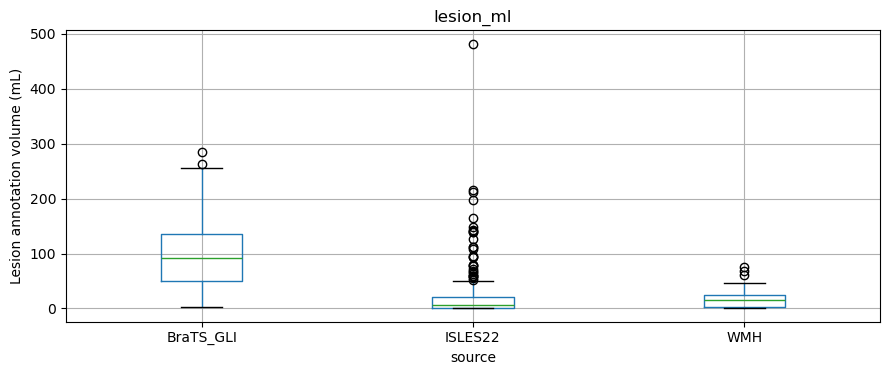

In [16]:
MAX_CASES_PER_SOURCE = None
voxels = pd.DataFrame()
if HAS_NIBABEL and not headers.empty:
    voxels = rg.voxel_audit(headers, max_cases_per_source=MAX_CASES_PER_SOURCE, seed=42)
    voxels.to_csv(EDA_DIR / 'voxel_mask_qc.csv',index=False)
    display(voxels.head())
    if not voxels.empty:
        display(voxels.groupby(['source','qc_status']).size().rename('audited_cases'))
        if 'lesion_ml' in voxels:
            display(voxels.groupby('source').lesion_ml.describe())
            finite_volumes = voxels.loc[voxels.lesion_ml.notna()]
            if not finite_volumes.empty:
                finite_volumes.boxplot(column='lesion_ml',by='source',figsize=(9,4))
                plt.suptitle(''); plt.ylabel('Lesion annotation volume (mL)'); plt.tight_layout(); plt.show()
else:
    print('Voxel QC unavailable.')


### Full-sequence intensity QC
All 2,460 MRI sequences were read successfully, with no NaN or Inf values. Compare percentiles within each source and modality.


In [17]:
intensities = rg.image_intensity_audit(headers, existing=voxels)
intensities.to_csv(EDA_DIR / 'image_intensity_qc.csv',index=False)
display(intensities.groupby(['source','qc_status']).size().rename('sequences'))
display(intensities.groupby('source').image_nonfinite.sum().rename('nonfinite_voxels'))


source     qc_status
BraTS_GLI  read_ok      920
BraTS_MEN  read_ok      920
ISLES22    read_ok      500
WMH        read_ok      120
Name: sequences, dtype: int64

source
BraTS_GLI    0
BraTS_MEN    0
ISLES22      0
WMH          0
Name: nonfinite_voxels, dtype: int64

## 14. Image–mask–report examples
Show one example per source in three canonical RAS planes.


Image: BraTS-GLI-00006-000-t1c | modality: T1CE
Modal finding: After contrast administration (T1C), the lesion in the left frontal lobe shows marked ring-like enhancement and maintains the aforementioned dimensions and effects on the surrounding structures.
Impression: A lesion with an approximately round abnormal signal in the left frontal lobe accompanied by extensive brain parenchyma edema, compression of the anterior horns of the bilateral lateral ventricles, and deviation of midline structures to the right is noted. Consideration for a malignant tumor, with glioblastoma being a high possibility.


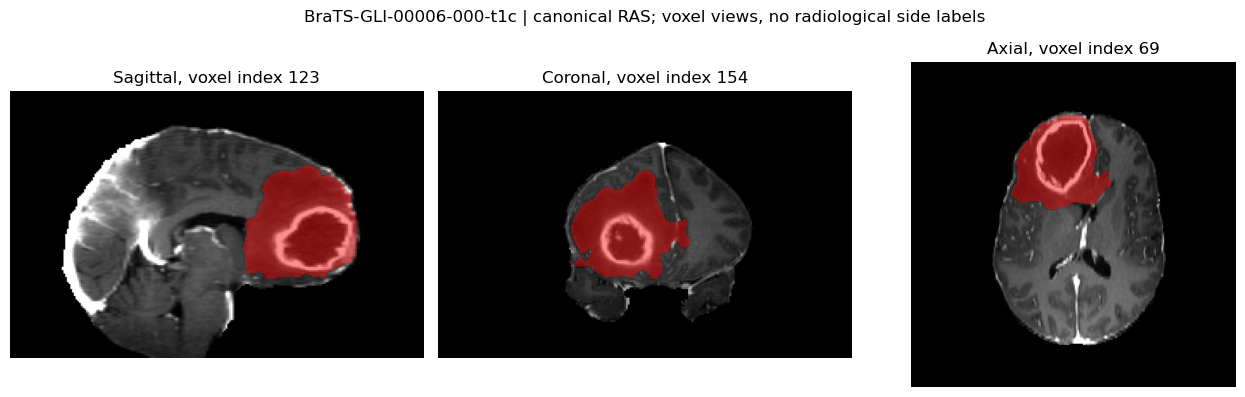

Image: BraTS-MEN-00017-000-t1c | modality: T1CE
Modal finding: After contrast administration, the lesion in the left cerebellopontine angle region demonstrates marked enhancement, indicative of significant contrast uptake, with well-defined boundaries, and no evidence of surrounding edema or distortion of neighboring midline structures.
Impression: A lesion in the left cerebellopontine angle region, likely a meningioma.


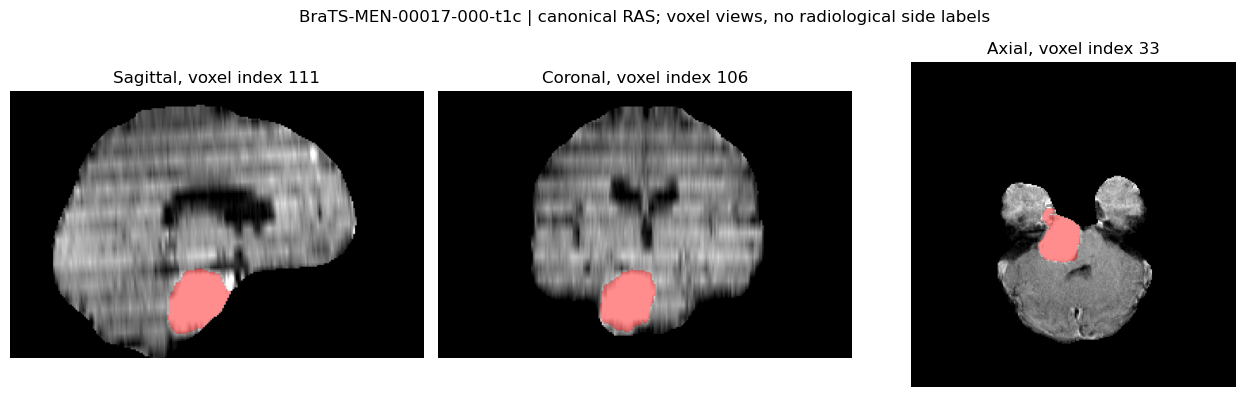

Image: sub-strokecase0001_ses-0001_adc | modality: ADC
Modal finding: The lesions demonstrate low signal intensity on ADC sequences, involving the left frontal-parietal lobes, bilateral occipital lobes, area adjacent to the left lateral ventricle, thalamus, and bilateral cerebellum. There is no midline shift.
Impression: Small patchy infarctions in the left frontal-parietal lobes, bilateral occipital lobes, area adjacent to the left lateral ventricle, thalamus, and bilateral cerebellum (in the subacute phase). Please correlate clinically.


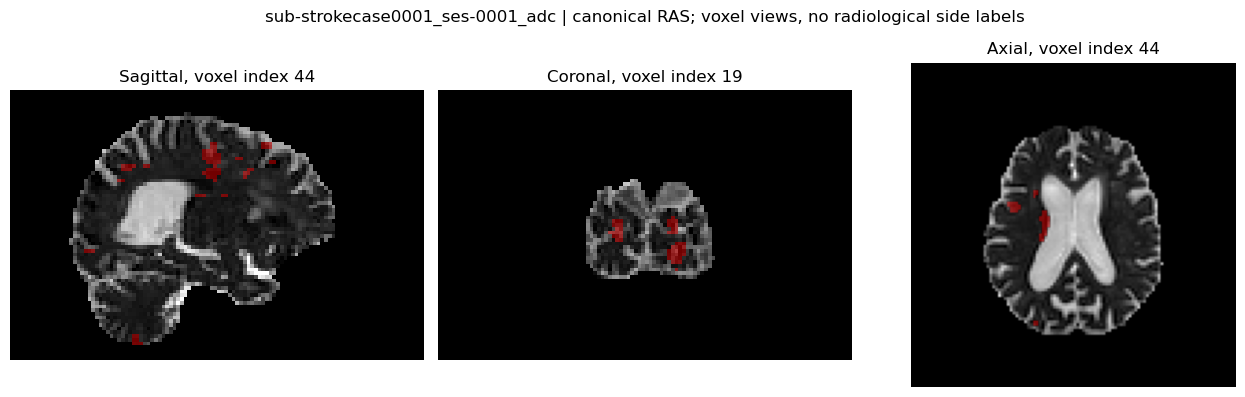

Image: GE3T_100_T1 | modality: T1WI
Modal finding: [MISSING]
Impression: Periventricular white matter degeneration.


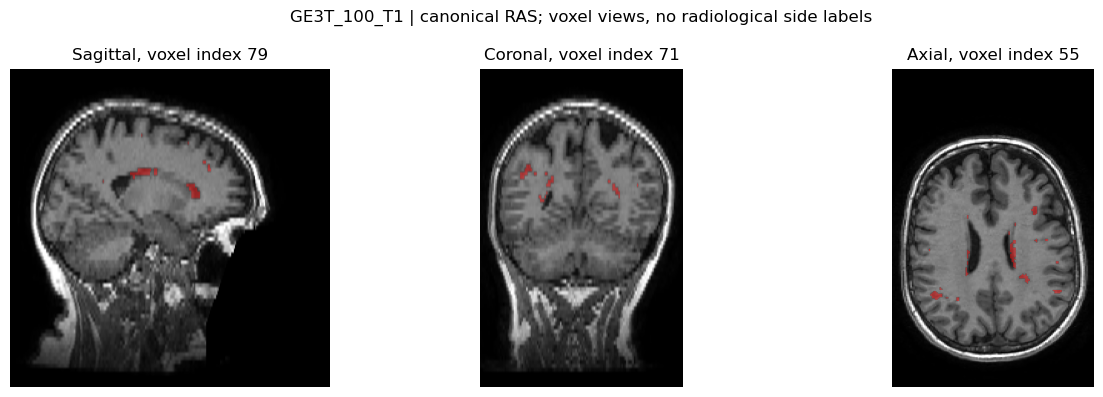

In [18]:
if not voxels.empty and 'mask_valid' in voxels:
    examples = voxels.loc[voxels.mask_valid.eq(True) & voxels.image_nonfinite.eq(0)].groupby('source').head(1)
    for r in examples.itertuples(index=False):
        paired = manifest.loc[manifest.image_id.eq(r.image_id)].iloc[0]
        print('Image:',r.image_id,'| modality:',paired.modality)
        print('Modal finding:',paired.modal_finding if pd.notna(paired.modal_finding) else '[MISSING]')
        print('Impression:',paired.impression)
        fig = rg.plot_overlay(r.image_path,r.lesion_mask_path,r.source,title=r.image_id)
        fig.savefig(EDA_DIR / 'figures' / f'{r.image_id}_overlay.png',dpi=150,bbox_inches='tight')
        plt.show()
else:
    print('No eligible overlay pairs.')


## 15. Exact-file duplicates
No byte-identical images were found among 2,460 SHA-256 hashes. Equivalent voxel arrays with different file encoding may still differ in hash.


In [19]:
RUN_IMAGE_HASHES = True
image_hashes = pd.DataFrame()
if RUN_IMAGE_HASHES:
    valid = manifest.loc[manifest.image_status.isin(['matched','manual_override'])]
    image_hashes = valid[['source','image_id','case_id','split','image_path']].copy()
    image_hashes['sha256'] = image_hashes.image_path.map(rg.file_sha256)
    image_hashes.to_csv(EDA_DIR / 'image_hashes.csv',index=False)
    display(image_hashes.loc[image_hashes.sha256.duplicated(keep=False)].sort_values('sha256'))
else:
    print('Image hashing disabled.')


,source,image_id,case_id,split,image_path,sha256


## 16. Review worksheet
Sample training pairs for manual review. Preserve existing notes.


In [20]:
eligible_ids = set(headers.loc[headers.geometry_ok, 'image_id']) if not headers.empty else set()
train_review = manifest.loc[manifest.split.eq('train') & manifest.modal_finding.notna()
                            & manifest.image_id.isin(eligible_ids)]
review = train_review.groupby('source',group_keys=False).apply(
    lambda g:g.sample(n=min(5,len(g)),random_state=42), include_groups=False).reset_index()
review = review[[c for c in ['source','case_id','image_id','modality','image_path','lesion_mask_path','modal_finding','impression'] if c in review]]
review_columns = ['side_consistency','location_consistency','modality_consistency','mask_coverage','review_notes']
for col in review_columns:
    review[col] = ''
review_path = EDA_DIR / 'manual_image_text_review.csv'
if review_path.exists():
    previous = pd.read_csv(review_path).fillna('')
    review = pd.concat([previous,review],ignore_index=True).drop_duplicates('image_id',keep='first')
    by_id = manifest.set_index('image_id')
    for col in ['image_path','lesion_mask_path']:
        review[col] = review.image_id.map(by_id[col])
review.to_csv(review_path,index=False)
print('Review worksheet refreshed; existing human annotations retained:', review_path)
print('Rows:',len(review),'| currently geometry-eligible:',int(review.image_id.isin(eligible_ids).sum()))


Review worksheet refreshed; existing human annotations retained: D:\Research\brain_vlm_xai\datasets\RadGenome-Brain_MRI\eda\manual_image_text_review.csv
Rows: 34 | currently geometry-eligible: 29


## 17. Summary
Separate data completeness from research readiness.


In [21]:
summary = {
    'hf_revision': HF_REVISION,
    'original_release_image_ids': len(all_annotations),
    'deferred_sources': DEFERRED_SOURCES,
    'excluded_archives': sorted(EXCLUDED_ARCHIVES),
    'archive_errors': archive_inventory.loc[archive_inventory.archive_status.ne('readable'), ['source','archive','archive_status']].to_dict('records'),
    'eda_completed_for_readable_active_sources': True,
    'image_ids': len(manifest),
    'cases': len(manifest[['source','case_id']].drop_duplicates()),
    'available_modal_reports': int(manifest.modal_finding.notna().sum()),
    'missing_modal_reports': int(manifest.modal_finding.isna().sum()),
    'local_images_matched': int(manifest.image_status.isin(['matched','manual_override']).sum()),
    'local_masks_matched_sequence_rows': int(manifest.lesion_mask_status.isin(['matched','manual_override']).sum()),
    'patient_proxy_split_overlap_groups': int(leakage.level.eq('patient_id_proxy').sum()),
    'header_qc_rows': len(headers),
    'images_header_attempted': int(headers.qc_status.ne('missing_image').sum()) if not headers.empty else 0,
    'voxel_cases_audited': len(voxels),
    'cohort_masks_audited': len(cohort_masks),
    'image_intensity_rows': len(intensities),
    'image_intensity_read_errors': int(intensities.qc_status.eq('read_error').sum()),
    'image_hash_rows': len(image_hashes),
    'empty_masks': int(cohort_masks.empty_mask.eq(True).sum()),
    'cohort_mask_read_errors': int(cohort_masks.qc_status.eq('read_error').sum()) if not cohort_masks.empty else 0,
    'geometry_aligned_sequence_rows': int(headers.geometry_ok.sum()) if not headers.empty else 0,
    'research_ready': False,
    'pending': 'Release mapping; patient overlap resolution; image-text review',
    'archive_mode': 'ZIP and local NIfTI; no volume disk cache',
    'max_volume_decompressed_mib': rg.MAX_VOLUME_BYTES // 1024**2,
}
display(pd.Series(summary))
(EDA_DIR / 'summary.json').write_text(json.dumps(summary,indent=2,ensure_ascii=False),encoding='utf-8')
coverage.to_csv(EDA_DIR / 'annotation_coverage.csv')
text_df[['source','image_id','modality','word_count','char_count']].to_csv(EDA_DIR / 'text_statistics.csv',index=False)
print('Manifest:', PROCESSED_DIR / 'image_report_manifest.csv')
print('EDA:', EDA_DIR)


hf_revision                                           0348ba42fad134da57b50e736ba858a8e73eb086
original_release_image_ids                                                                3408
deferred_sources                                     {'BraTS_MET': 'Excluded by user request'}
excluded_archives                                                 [BraTS-MEN-TRAIN-FIX-V4.zip]
archive_errors                                                                              []
eda_completed_for_readable_active_sources                                                 True
image_ids                                                                                 2460
cases                                                                                      770
available_modal_reports                                                                   2150
missing_modal_reports                                                                      310
local_images_matched                              

Manifest: D:\Research\brain_vlm_xai\datasets\RadGenome-Brain_MRI\processed\image_report_manifest.csv
EDA: D:\Research\brain_vlm_xai\datasets\RadGenome-Brain_MRI\eda


### Storage usage


In [22]:
disk_end = shutil.disk_usage(DATA_ROOT)
eda_bytes_after = sum(p.stat().st_size for p in DATA_ROOT.rglob('*') if p.is_file()
                      and ('eda' in p.parts or 'processed' in p.parts))
storage = {'completed_at_utc':datetime.datetime.now(datetime.timezone.utc).isoformat(),
           'disk_free_gib':disk_end.free / 1024**3,
           'eda_processed_total_mib':eda_bytes_after / 1024**2,
           'eda_processed_growth_mib':(eda_bytes_after-eda_bytes_before) / 1024**2,
           'archive_extracted':False, 'volume_disk_cache_created':False}
display(pd.Series(storage))
(EDA_DIR / 'storage_usage.json').write_text(json.dumps(storage,indent=2),encoding='utf-8')


completed_at_utc             2026-10-03T05:55:31.756101+00:00
disk_free_gib                                        9.414028
eda_processed_total_mib                             16.922764
eda_processed_growth_mib                             2.580129
archive_extracted                                       False
volume_disk_cache_created                               False
dtype: object

263

### Intensity by modality
Use all matched MRI sequences. Raw MRI intensities are not directly comparable across modalities.


In [23]:
if not intensities.empty:
    intensity_summary = intensities.groupby(['source','modality'])[['p01','p50','p99']].agg(['count','median'])
    display(intensity_summary)
    intensity_summary.to_csv(EDA_DIR / 'intensity_by_modality.csv')


p01          p50             p99             
                   count median count    median count       median
source    modality                                                
BraTS_GLI T1CE       230    0.0   230  0.000000   230   652.000000
          T1WI       230    0.0   230  0.000000   230   556.500000
          T2FLAIR    230    0.0   230  0.000000   230   459.500000
          T2WI       230    0.0   230  0.000000   230  1134.500000
BraTS_MEN T1CE       230    0.0   230  0.000000   230   991.564833
          T1WI       230    0.0   230  0.000000   230   647.127656
          T2FLAIR    230    0.0   230  0.000000   230   466.039850
          T2WI       230    0.0   230  0.000000   230  1008.252143
ISLES22   ADC        250    0.0   250  0.000000   250     2.661278
          DWI        250    0.0   250  0.000000   250   312.680839
WMH       T1WI        60    0.0    60  6.000000    60  1458.500000
          T2FLAIR     60    0.0    60  6.218599    60   855.034456

### Case coverage and mask size
Show case coverage and one mask-size observation per case.


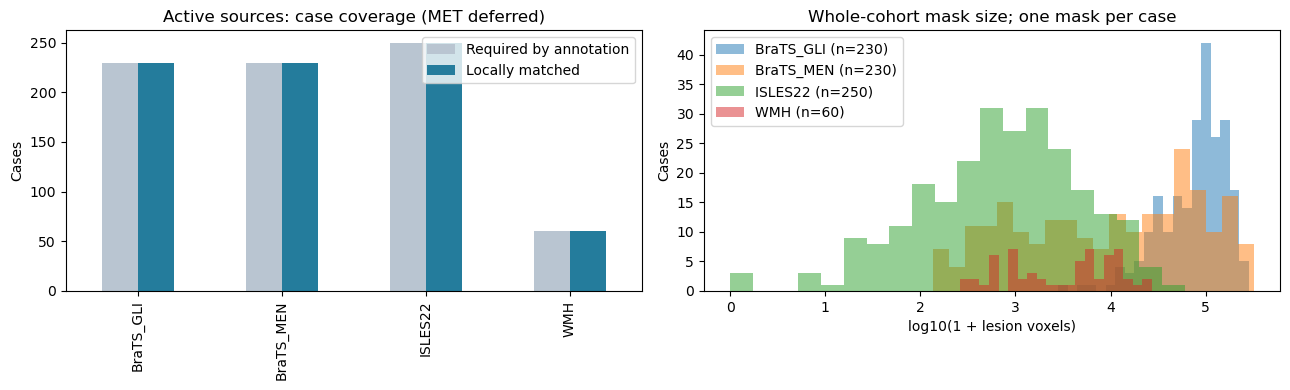

Physical volumes are withheld for MEN (unknown units) and ISLES geometry conflicts.


In [24]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plot_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'notebooks/radgenome_utils.py').exists())
plot_eda = plot_root / 'datasets/RadGenome-Brain_MRI/eda'
plot_masks = pd.read_csv(plot_eda / 'cohort_mask_qc.csv')
plot_coverage = pd.read_csv(plot_eda / 'local_source_coverage.csv').set_index('source')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_coverage[['required_cases','local_cases']].plot.bar(ax=axes[0], color=['#b9c5d1','#247c9c'])
axes[0].set(title='Active sources: case coverage (MET deferred)', ylabel='Cases', xlabel='')
axes[0].legend(['Required by annotation','Locally matched'])
for source, group in plot_masks.groupby('source'):
    values = np.log10(1 + group.loc[group.mask_valid, 'lesion_voxels'])
    axes[1].hist(values,bins=20,alpha=.5,label=f'{source} (n={len(values)})')
axes[1].set(title='Whole-cohort mask size; one mask per case', xlabel='log10(1 + lesion voxels)', ylabel='Cases')
axes[1].legend()
fig.tight_layout()
fig.savefig(plot_eda / 'figures/cohort_coverage_and_mask_size.png',dpi=150)
plt.show()
print('Physical volumes are withheld for MEN (unknown units) and ISLES geometry conflicts.')


## Key findings

- Complete image–mask coverage for all 770 active cases; MET remains excluded.
- Reports are missing for ISLES DWI and WMH T1.
- Review seven geometry-flagged cases, MEN spatial units, and three cross-split patient proxies before evaluation.

Details: [EDA report](../docs/eda/RADGENOME.md).
